In [111]:
%reload_ext autoreload
%autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=4, seed=42,back_cam=False)
controller = Controller(sim)

for _ in trange(10000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

100%|██████████| 10000/10000 [00:21<00:00, 475.35it/s]


birdeyecam This browser does not support the video tag.


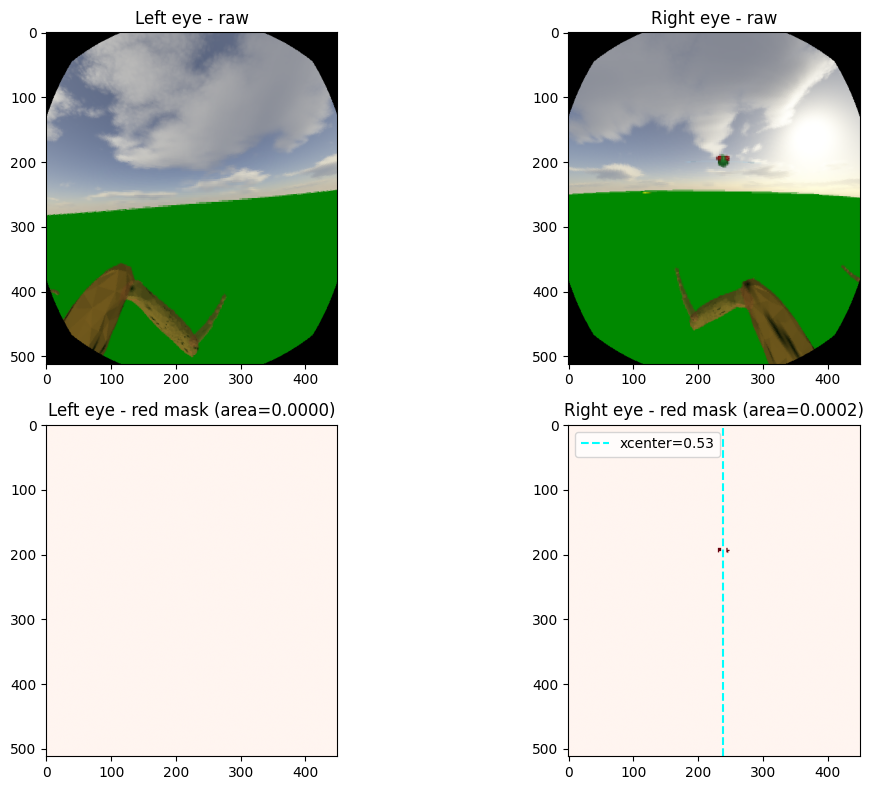

Eye 0: dtype=uint8  range=[0, 226]  shape=(512, 450, 3)
Eye 1: dtype=uint8  range=[0, 255]  shape=(512, 450, 3)


In [106]:
import matplotlib.pyplot as plt

raw_vision = sim.get_raw_vision(sim.fly.name)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, title in enumerate(["Left eye", "Right eye"]):
    eye = raw_vision[i]

    # show raw image
    axes[0, i].imshow(eye)
    axes[0, i].set_title(f"{title} - raw")

    # show red mask
    r = eye[..., 0].astype(np.float32)
    g = eye[..., 1].astype(np.float32)
    b = eye[..., 2].astype(np.float32)
    red_frac = r / (r + g + b + 1e-6)
    is_red = red_frac > 0.6
    axes[1, i].imshow(is_red, cmap="Reds")
    axes[1, i].set_title(f"{title} - red mask (area={is_red.mean():.4f})")
    if is_red.any():
        _, cols = np.where(is_red)
        axes[1, i].axvline(cols.mean(), color="cyan", ls="--", label=f"xcenter={cols.mean()/eye.shape[1]:.2f}")
        axes[1, i].legend()

plt.tight_layout()
plt.show()

# print dtype and value ranges to verify thresholds
for i, eye in enumerate(raw_vision):
    print(f"Eye {i}: dtype={eye.dtype}  range=[{eye.min()}, {eye.max()}]  shape={eye.shape}")

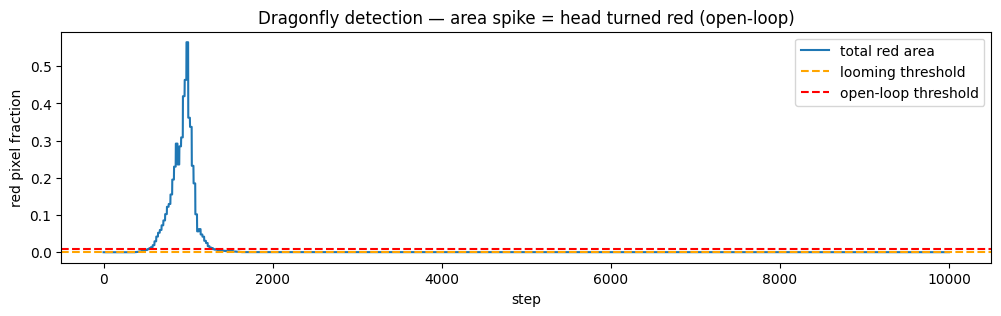

In [100]:
import matplotlib.pyplot as plt

def detect_red(raw_vision, red_ratio=0.6):
    """
    Same idea as VisualTaxisController._process_visual_observation
    but detects red pixels in raw vision instead of dark ommatidia.
    Returns [(area_L, xcenter_L), (area_R, xcenter_R)].
    """
    results = []
    for eye_img in raw_vision:
        r = eye_img[..., 0].astype(np.float32)
        g = eye_img[..., 1].astype(np.float32)
        b = eye_img[..., 2].astype(np.float32)
        # R must be >60% of total brightness (works for both uint8 and float)
        is_red = (r / (r + g + b + 1e-6)) > red_ratio
        area = is_red.mean()
        if area > 0:
            _, cols = np.where(is_red)
            xcenter = cols.mean() / eye_img.shape[1]
        else:
            xcenter = 0.5
        results.append((area, xcenter))
    return results


# run sim for a while, collect data
areas = []
for step in range(10000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()

    raw_vision = sim.get_raw_vision(sim.fly.name)
    (a_l, _), (a_r, _) = detect_red(raw_vision)
    areas.append(a_l + a_r)

plt.figure(figsize=(12, 3))
plt.plot(areas, label="total red area")
plt.axhline(0.001, color="orange", ls="--", label="looming threshold")
plt.axhline(0.01, color="red", ls="--", label="open-loop threshold")
plt.ylabel("red pixel fraction")
plt.xlabel("step")
plt.legend()
plt.title("Dragonfly detection — area spike = head turned red (open-loop)")
plt.show()

In [102]:
import numpy as np
import tqdm
from flygym.compose import ActuatorType
from miniproject import MiniprojectSimulation
from submission.controller import Controller

MAX_NUM_STEPS = 100000
NUM_SEEDS = 10
LEVEL = 4  # change as needed
SUCCESS_RADIUS = 3.0

def run_single_seed(seed):
    sim = MiniprojectSimulation(level=LEVEL, seed=seed, back_cam=False, top_cam=False)
    controller = Controller(sim)

    def get_distance():
        fly_xy = np.array(sim.get_body_positions(sim.fly.name)[0][:2])
        banana_xy = np.array(sim.world.banana_xy)
        return np.linalg.norm(fly_xy - banana_xy)

    for step in range(MAX_NUM_STEPS):
        dist = get_distance()
        if dist <= SUCCESS_RADIUS:
            print(f"  seed={seed} → reached banana in {step} steps (dist={dist:.2f})")
            return dist

        joint_angles, adhesion_signals = controller.step(sim)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion_signals)
        sim.step()

    final_dist = get_distance()
    print(f"  seed={seed} → timed out (final dist={final_dist:.2f})")
    return final_dist


distances = []
seeds = np.random.randint(0, 101, size=NUM_SEEDS)
for seed in tqdm.tqdm(seeds):
    d = run_single_seed(int(seed))
    distances.append(d)

distances = np.array(distances)
print(f"\n--- Results over {NUM_SEEDS} seeds ---")
print(f"  Mean final distance : {distances.mean():.2f}")
print(f"  Std                 : {distances.std():.2f}")
print(f"  Min / Max           : {distances.min():.2f} / {distances.max():.2f}")
print(f"  Success rate (≤{SUCCESS_RADIUS}mm): {(distances <= SUCCESS_RADIUS).mean()*100:.0f}%")

  0%|          | 0/10 [03:50<?, ?it/s]


KeyboardInterrupt: 